# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
## 1. Replace corpus with your own paragraph
corpus = """
artificial intelligence requires massive computing power and storage capacity
modern ai data centers are built to handle extreme computational workloads
high performance gpus process billions of parameters across multiple neural networks
to feed these processors vector databases store and retrieve vast amounts of unstructured data
traditional relational databases struggle with the speed required for machine learning
instead scalable cloud infrastructure and distributed file systems manage the information
liquid cooling systems in these data centers consume significant amounts of energy
optimizing data pipelines ensures that deep learning models train faster and efficiently
the synergy between advanced databases and ai data centers drives constant innovation
as artificial intelligence grows these modern data centers must evolve to meet demand
"""

print(corpus)


artificial intelligence requires massive computing power and storage capacity
modern ai data centers are built to handle extreme computational workloads
high performance gpus process billions of parameters across multiple neural networks
to feed these processors vector databases store and retrieve vast amounts of unstructured data
traditional relational databases struggle with the speed required for machine learning
instead scalable cloud infrastructure and distributed file systems manage the information
liquid cooling systems in these data centers consume significant amounts of energy
optimizing data pipelines ensures that deep learning models train faster and efficiently
the synergy between advanced databases and ai data centers drives constant innovation
as artificial intelligence grows these modern data centers must evolve to meet demand



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 88
X shape: (106, 13)
y shape: (106,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 36, input_length=max_len-1), ##2.Increase embedding dimension for 32 to 36
    SimpleRNN(128), ## 4.Change hidden units 64 → 128
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0) ## 3. Increase epochs to 200
print("Vanilla RNN training completed")

c:\Users\nipun\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 36, input_length=max_len-1), ##2.Increase embedding dimension for 32 to 36
    LSTM(128), ## 4.Change hidden units 64 → 128
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0) ## 3. Increase epochs to 200
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 36, input_length=max_len-1), ##2.Increase embedding dimension for 32 to 36
    GRU(128), ## 4.Change hidden units 64 → 128
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0) ## 3. Increase epochs to 200
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

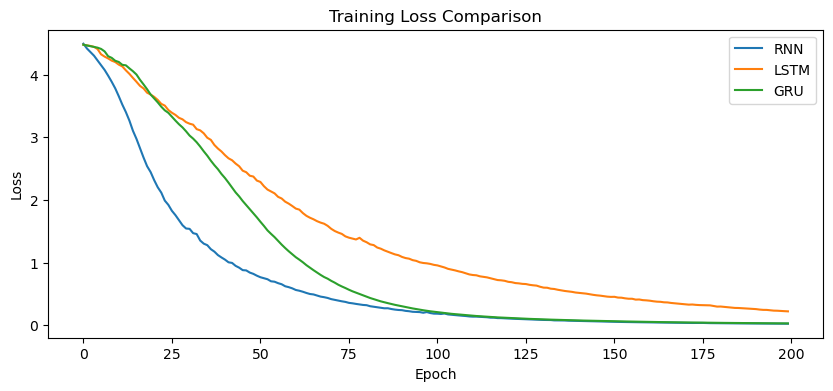

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=10): ## 5. Generate 10 words instead of 5
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "artificial intelligence"))
print("LSTM:", generate_text(lstm_model, "artificial intelligence"))
print("GRU :", generate_text(gru_model, "artificial intelligence"))

RNN : artificial intelligence requires massive computing power and storage capacity data centers are
LSTM: artificial intelligence requires massive computing power and storage capacity capacity computational demand
GRU : artificial intelligence requires massive computing power and storage capacity capacity unstructured data


# 🧠 Understanding Sequence Model Generation Artifacts

When generating text using sequence models (like Vanilla RNN, LSTM, and GRU) on very small datasets with strict probability decoding, two common artifacts occur: **Context Stitching (Hallucination)** and **The Repetition Trap**.

## 1. Context Stitching (The "Hallucination" Effect)
* **Observed Behavior:** The model seamlessly glues completely unrelated lines of the training corpus together (e.g., combining "storage capacity" with "machine learning energy").
* **Why it happens:** Neural networks do not inherently understand English grammar or semantic meaning; they calculate mathematical probabilities. When the model reaches a word like "capacity," it must guess the next word based on its hidden state. If the dataset is tiny, it simply picks the highest probable word in its entire matrix that mathematically fits, bridging two unrelated sentences together to satisfy the length requirement.

## 2. The Repetition Trap
* **Observed Behavior:** The model outputs the same word repeatedly in a loop (e.g., "capacity capacity capacity").
* **Why it happens:** This is a direct consequence of using **Greedy Search** (`np.argmax`) on a small dataset. When the model is unsure of the next word, Greedy Search forces it to pick the #1 highest mathematical probability, even if the margin is tiny. Once a word repeats, the model's short-term context window becomes flooded with that same word, causing it to confidently predict it again and getting stuck in an infinite loop.

---

## 🛠️ The Engineering Solutions
In production systems and Large Language Models, engineers solve these artifacts by replacing the naive `np.argmax` (Greedy Search) with advanced decoding algorithms:

1. **Temperature Scaling:** Introduces controlled mathematical randomness to the probability distribution before picking the next word. This allows the model to occasionally pick the 2nd or 3rd most likely word, making the text more creative and breaking repetition loops.
2. **Top-K / Top-p (Nucleus) Sampling:** Restricts the model's choices to only a curated pool of highly probable words, ensuring the output is dynamic but still grammatically coherent.
3. **Beam Search:** Instead of guessing just one word at a time, the model explores multiple possible *paths* (beams) of words simultaneously and chooses the sequence with the highest overall probability.

In [11]:
print("RNN :", generate_text(rnn_model, "databases"))
print("LSTM:", generate_text(lstm_model, "databases"))
print("GRU :", generate_text(gru_model, "databases"))

RNN : databases feed ai data centers are built to handle extreme computational
LSTM: databases synergy between advanced databases and ai data centers constant constant
GRU : databases cooling systems in these data centers consume significant amounts of


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**